# Zadanie 2. Klienci hurtowni - KMeans

Plik `Wholesale customers data.csv` zawiera roczne wydatki (w jednostkach pieniężnych) klientów portugalskiego dystrybutora w 6 kategoriach produktów. Zmienne `Channel` i `Region` są kategoryczne..

## Import bibliotek

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

import warnings
warnings.filterwarnings('ignore')
sns.set_theme()

## Wczytanie danych

In [77]:
df = pd.read_csv('Wholesale customers data.csv')
print('Wymiar:', df.shape)
df.head()

Wymiar: (440, 8)


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


## Eksploracja danych

In [78]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


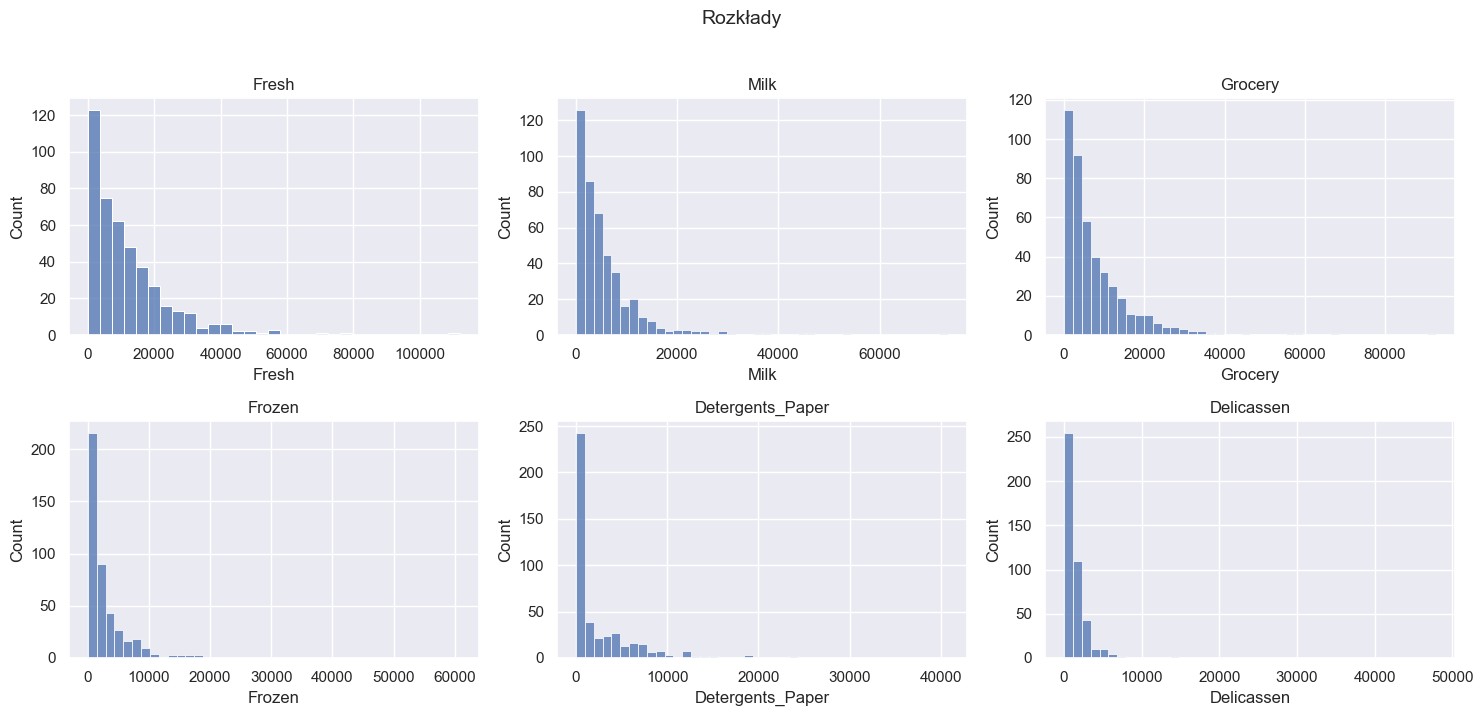

In [79]:
spend_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.flatten(), spend_cols):
    sns.histplot(df[col], ax=ax)
    ax.set_title(col)
fig.suptitle('Rozkłady', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### Rozkład zmiennych kategorycznych

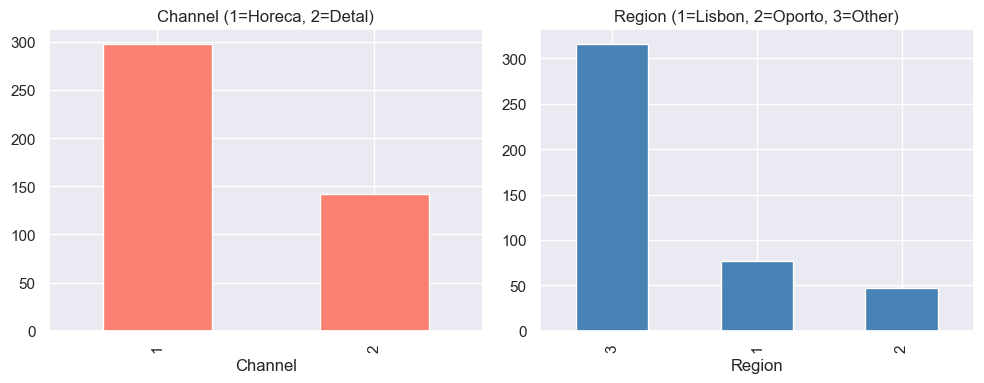

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df['Channel'].value_counts().plot(kind='bar', ax=axes[0], color='salmon', edgecolor='white')
axes[0].set_title('Channel (1=Horeca, 2=Detal)')
df['Region'].value_counts().plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Region (1=Lisbon, 2=Oporto, 3=Other)')
plt.tight_layout()
plt.show()

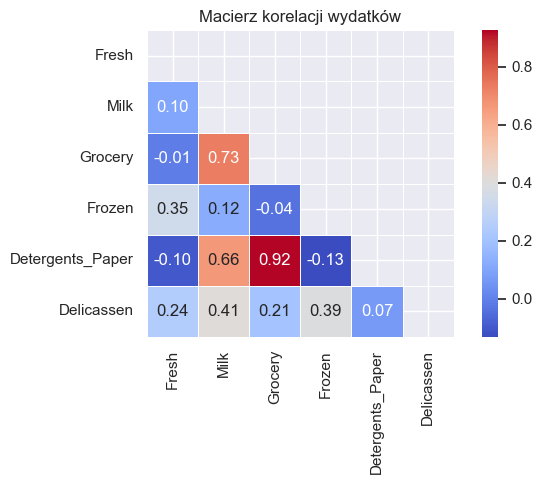

In [81]:
plt.figure(figsize=(7, 5))
corr = df[spend_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Macierz korelacji wydatków')
plt.tight_layout()
plt.show()

In [82]:
df.duplicated().sum()

np.int64(0)

In [83]:
print('Channel:', sorted(df['Channel'].unique()))
print('Region: ', sorted(df['Region'].unique()))

Channel: [np.int64(1), np.int64(2)]
Region:  [np.int64(1), np.int64(2), np.int64(3)]


In [84]:
df_enc = pd.get_dummies(df, columns=['Channel', 'Region'], dtype=int)

df_enc.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Channel_1,Channel_2,Region_1,Region_2,Region_3
0,12669,9656,7561,214,2674,1338,0,1,0,0,1
1,7057,9810,9568,1762,3293,1776,0,1,0,0,1
2,6353,8808,7684,2405,3516,7844,0,1,0,0,1
3,13265,1196,4221,6404,507,1788,1,0,0,0,1
4,22615,5410,7198,3915,1777,5185,0,1,0,0,1


## Standaryzacja

In [85]:
scaler = StandardScaler()
X = scaler.fit_transform(df_enc)
print('Kształt macierzy cech:', X.shape)

Kształt macierzy cech: (440, 11)


### KMeans - metoda łokcia + silhouette

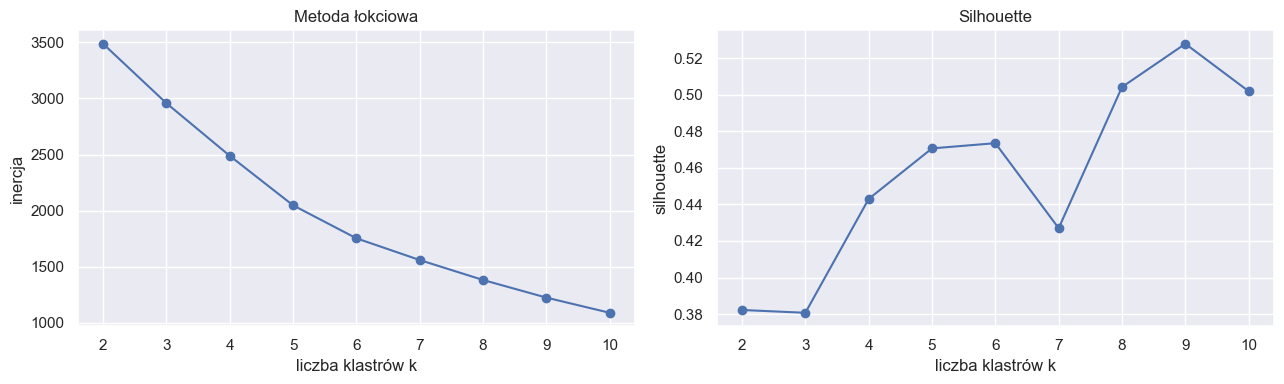

Najlepszy k wg silhouette: 9


In [86]:
inertias = []
sils = []
ks = range(2, 11)
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(list(ks), inertias, 'o-')
ax[0].set_xlabel('liczba klastrów k'); ax[0].set_ylabel('inercja')
ax[0].set_title('Metoda łokciowa')
ax[1].plot(list(ks), sils, 'o-')
ax[1].set_xlabel('liczba klastrów k'); ax[1].set_ylabel('silhouette')
ax[1].set_title('Silhouette')
plt.tight_layout(); plt.show()
print('Najlepszy k wg silhouette:', list(ks)[int(np.argmax(sils))])

### KMeans – wynik

In [87]:
best_k = list(ks)[int(np.argmax(sils))]
km = KMeans(n_clusters=best_k, n_init=10, random_state=42).fit(X)
labels_km = km.labels_
print(f'k = {best_k}')
print(f'Inercja:          {km.inertia_:.2f}')
print(f'Silhouette score: {silhouette_score(X, labels_km):.3f}')

k = 9
Inercja:          1225.25
Silhouette score: 0.528


### Charakterystyka klastrów (średnie wydatki)

In [88]:
# Srednie wydatki w skali oryginalnej dla kazdego klastra
df_with_cluster = df.copy()
df_with_cluster['cluster'] = labels_km

profile = df_with_cluster.groupby('cluster')[spend_cols].mean().round(2)

print('Średnie wydatki na klaster:')
print(profile)

Średnie wydatki na klaster:
            Fresh      Milk   Grocery    Frozen  Detergents_Paper  Delicassen
cluster                                                                      
0         9001.07   8514.81  13488.04   1389.68           5643.68     1598.01
1        11538.78   3028.57   3574.31   2873.58            770.94     1167.55
2        16911.09  34864.36  46126.18   3245.45          23008.09     4177.36
3        12596.71   3812.64   4011.12   2858.64            953.76     1168.21
4        36847.00  43950.00  20170.00  36534.00            239.00    47943.00
5        47863.21   8295.71   7910.07  17548.86           1081.43     3551.79
6         7218.94   9424.72  13494.56   1618.89           6760.72     1240.33
7        10870.30   1767.96   4053.63   3703.41            453.48      939.11
8         4709.19   8915.81  16200.94   2189.50           6878.19     1606.50


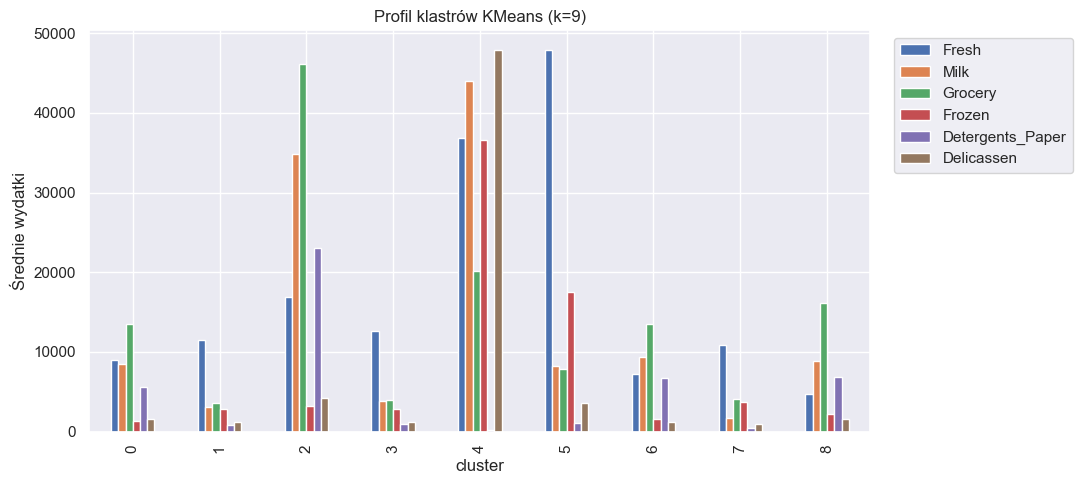

In [89]:
ax = profile.plot(kind='bar', figsize=(11, 5))
ax.set_ylabel('Średnie wydatki')
ax.set_title(f'Profil klastrów KMeans (k={best_k})')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.show()

### Wizualizacja klastrów (PCA)

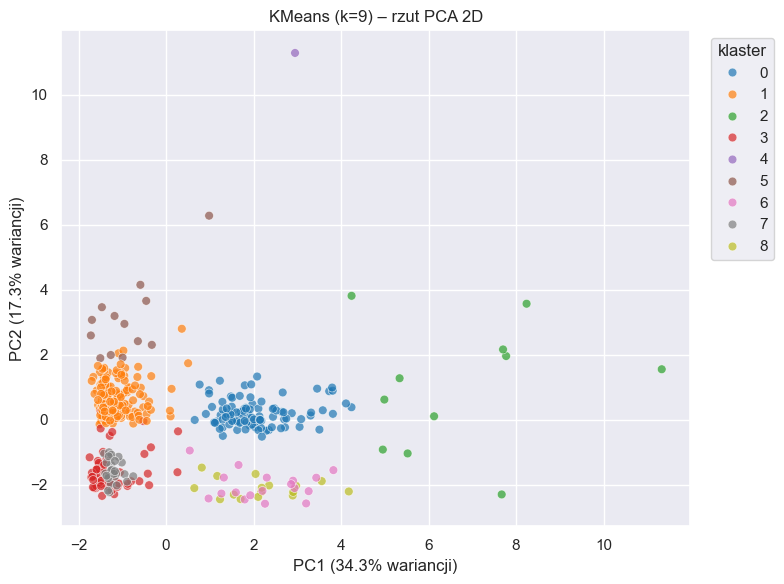

In [90]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels_km,
                palette='tab10', alpha=0.7, s=40)
plt.title(f'KMeans (k={best_k}) – rzut PCA 2D')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% wariancji)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% wariancji)')
plt.legend(title='klaster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.show()

## Podsumowanie

In [91]:
summary = pd.DataFrame({
    'algorytm': ['KMeans'],
    'liczba_klastrow': [best_k],
    'silhouette': [round(silhouette_score(X, labels_km), 3)]
})
print(summary.to_string(index=False))

algorytm  liczba_klastrow  silhouette
  KMeans                9       0.528


## Analiza i interpretacja klastrów

### Średnie wartości zmiennych w każdej grupie

In [92]:
spend_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
df_with_cluster = df.copy()
df_with_cluster['cluster'] = labels_km

profile = df_with_cluster.groupby('cluster')[spend_cols].mean().round(0).astype(int)
profile['n_klientow'] = df_with_cluster.groupby('cluster')['Fresh'].count()

print('Średnie roczne wydatki i liczba klientów w każdym klastrze:')
profile

Średnie roczne wydatki i liczba klientów w każdym klastrze:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,n_klientow
cluster,,,,,,,
0,9001,8515,13488,1390,5644,1598,97
1,11539,3029,3574,2874,771,1168,198
2,16911,34864,46126,3245,23008,4177,11
3,12597,3813,4011,2859,954,1168,58
4,36847,43950,20170,36534,239,47943,1
5,47863,8296,7910,17549,1081,3552,14
6,7219,9425,13495,1619,6761,1240,18
7,10870,1768,4054,3703,453,939,27
8,4709,8916,16201,2190,6878,1606,16


### Opisowe nazwy klastrów

Na podstawie dominujących kategorii wydatków nadajemy każdemu klastrowi opisową nazwę:

| Klaster | Nazwa opisowa | Dominująca cecha |
|---------|---------------|------------------|
| 0 | Średni odbiorcy detaliczni | Grocery + Detergents_Paper |
| 1 | Mali klienci gastronomiczni – świeże | Fresh > reszta, niskie Detergents |
| 2 | Duże sieci detaliczne | Bardzo wysokie Grocery, Milk, Detergents |
| 3, 7 | Mniejsi klienci HoReCa – świeże/mrożone | Fresh + Frozen, niskie Detergents |
| 4 | Outlier | Ekstremalne wartości we wszystkich kategoriach |
| 5 | Duzi odbiorcy HoReCa – świeże i mrożone | Najwyższe Fresh + Frozen |
| 6, 8 | Małe sklepy spożywcze | Grocery + Detergents, niskie Fresh |

In [93]:
cluster_names = {
    0: 'Średni odbiorcy detaliczni',
    1: 'Mali klienci gastronomiczni – świeże',
    2: 'Duże sieci detaliczne',
    3: 'Mniejsi klienci HoReCa – świeże/mrożone',
    4: 'Outlier',
    5: 'Duzi odbiorcy HoReCa – świeże i mrożone',
    6: 'Małe sklepy spożywcze',
    7: 'Mniejsi klienci HoReCa – świeże/mrożone',
    8: 'Małe sklepy spożywcze'
}

df_with_cluster['cluster_name'] = df_with_cluster['cluster'].map(cluster_names)

# Tabela profilu z nazwami
profile_named = df_with_cluster.groupby('cluster_name')[spend_cols].mean().round(0).astype(int)
profile_named['n_klientow'] = df_with_cluster.groupby('cluster_name')['Fresh'].count()
profile_named = profile_named.sort_values('n_klientow', ascending=False)
print('Profil klastrów z opisowymi nazwami:')
profile_named

Profil klastrów z opisowymi nazwami:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,n_klientow
cluster_name,,,,,,,
Mali klienci gastronomiczni – świeże,11539,3029,3574,2874,771,1168,198
Średni odbiorcy detaliczni,9001,8515,13488,1390,5644,1598,97
Mniejsi klienci HoReCa – świeże/mrożone,12048,3163,4025,3127,795,1095,85
Małe sklepy spożywcze,6038,9185,14768,1887,6816,1413,34
Duzi odbiorcy HoReCa – świeże i mrożone,47863,8296,7910,17549,1081,3552,14
Duże sieci detaliczne,16911,34864,46126,3245,23008,4177,11
Outlier,36847,43950,20170,36534,239,47943,1


### Rozkład klientów w klastrach według CHANNEL i REGION

In [94]:
# CHANNEL: 1 = HoReCa (gastronomia/hotele), 2 = Retail (detal)
channel_map = {1: 'HoReCa', 2: 'Retail'}
region_map  = {1: 'Lisbon', 2: 'Oporto', 3: 'Other'}

df_with_cluster['Channel_label'] = df_with_cluster['Channel'].map(channel_map)
df_with_cluster['Region_label']  = df_with_cluster['Region'].map(region_map)

# Tabela krzyżowa klaster × kanał
ct_channel = pd.crosstab(
    df_with_cluster['cluster_name'],
    df_with_cluster['Channel_label'],
    margins=True, margins_name='RAZEM'
)
ct_channel['% HoReCa'] = (ct_channel['HoReCa'] / ct_channel['RAZEM'] * 100).round(1)
print('Rozkład według kanału dystrybucji:')
ct_channel

Rozkład według kanału dystrybucji:


Channel_label,HoReCa,Retail,RAZEM,% HoReCa
cluster_name,,,,
Duzi odbiorcy HoReCa – świeże i mrożone,14,0,14,100.0
Duże sieci detaliczne,0,11,11,0.0
Mali klienci gastronomiczni – świeże,198,0,198,100.0
Małe sklepy spożywcze,0,34,34,0.0
Mniejsi klienci HoReCa – świeże/mrożone,85,0,85,100.0
Outlier,1,0,1,100.0
Średni odbiorcy detaliczni,0,97,97,0.0
RAZEM,298,142,440,67.7


In [95]:
# Tabela krzyżowa klaster × region
ct_region = pd.crosstab(
    df_with_cluster['cluster_name'],
    df_with_cluster['Region_label'],
    margins=True, margins_name='RAZEM'
)
print('Rozkład według regionu:')
ct_region

Rozkład według regionu:


Region_label,Lisbon,Oporto,Other,RAZEM
cluster_name,,,,
Duzi odbiorcy HoReCa – świeże i mrożone,1,1,12,14
Duże sieci detaliczne,2,1,8,11
Mali klienci gastronomiczni – świeże,0,0,198,198
Małe sklepy spożywcze,16,18,0,34
Mniejsi klienci HoReCa – świeże/mrożone,58,27,0,85
Outlier,0,0,1,1
Średni odbiorcy detaliczni,0,0,97,97
RAZEM,77,47,316,440


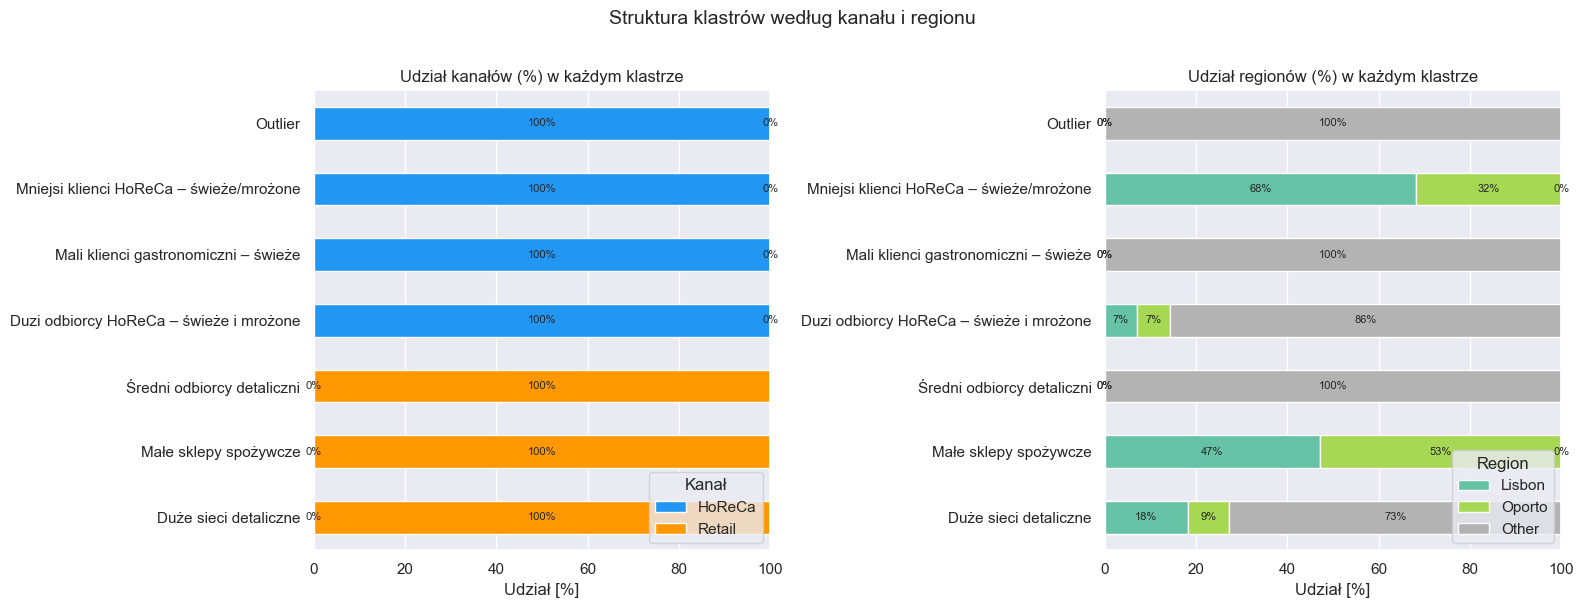

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Wykres 1: stacked bar – channel
ct_ch = pd.crosstab(df_with_cluster['cluster_name'], df_with_cluster['Channel_label'], normalize='index') * 100
ct_ch = ct_ch.sort_values('HoReCa', ascending=True)
ct_ch.plot(kind='barh', stacked=True, ax=axes[0], color=['#2196F3','#FF9800'], edgecolor='white')
axes[0].set_title('Udział kanałów (%) w każdym klastrze', fontsize=12)
axes[0].set_xlabel('Udział [%]')
axes[0].set_ylabel('')
axes[0].legend(title='Kanał', loc='lower right')
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.0f%%', label_type='center', fontsize=8)

# Wykres 2: stacked bar – region
ct_reg = pd.crosstab(df_with_cluster['cluster_name'], df_with_cluster['Region_label'], normalize='index') * 100
ct_reg = ct_reg.reindex(ct_ch.index)
ct_reg.plot(kind='barh', stacked=True, ax=axes[1], colormap='Set2', edgecolor='white')
axes[1].set_title('Udział regionów (%) w każdym klastrze', fontsize=12)
axes[1].set_xlabel('Udział [%]')
axes[1].set_ylabel('')
axes[1].legend(title='Region', loc='lower right')
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.0f%%', label_type='center', fontsize=8)

plt.suptitle('Struktura klastrów według kanału i regionu', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Podsumowanie

### Opis danych i metodologii

Analizowany zbiór pochodzi z portugalskiego dystrybutora hurtowego i zawiera **440 klientów** opisanych rocznymi wydatkami w **6 kategoriach produktów**: *Fresh* (świeże), *Milk* (nabiał), *Grocery* (artykuły spożywcze), *Frozen* (mrożone), *Detergents_Paper* (środki czystości i papiernicze), *Delicassen* (delikatesy). Dodatkowo dostępne są dwie zmienne kategoryczne:
- **Channel** – kanał dystrybucji: 1 = HoReCa (hotele, restauracje, kawiarnie), 2 = Retail (detal)
- **Region** – 1 = Lizbona, 2 = Oporto, 3 = Inne


### Wybór liczby klastrów

Metoda łokciowa wskazuje na spłaszczenie inercji po k = 3–4, jednak **współczynnik silhouette osiąga maksimum przy k = 9 (wartość ≈ 0.528)**, co sugeruje wyraźną separację grup przy tej liczbie klastrów. W związku z tym do dalszej analizy przyjęto **k = 9**.

### Charakterystyka grup

| Nazwa grupy | Główne cechy | Liczebność |
|-------------|--------------|------------|
| **Mali klienci gastronomiczni – świeże** | Najliczniejsza grupa; wysokie Fresh, niskie Detergents; 100% HoReCa | 198 |
| **Średni odbiorcy detaliczni** | Umiarkowane Grocery i Detergents; 100% Retail | 97 |
| **Mniejsi klienci HoReCa – świeże/mrożone** | Fresh + Frozen, niskie Detergents; wyłącznie HoReCa | 85 (kl. 3+7) |
| **Małe sklepy spożywcze** | Grocery + Detergents, niskie Fresh; wyłącznie Retail | 34 (kl. 6+8) |
| **Duzi odbiorcy HoReCa – świeże i mrożone** | Najwyższe Fresh (48k) i Frozen (18k); 100% HoReCa | 14 |
| **Duże sieci detaliczne** | Najwyższe Grocery (46k), Milk (35k), Detergents (23k); 100% Retail | 11 |
| **Outlier** | Ekstremalne wartości (Delicassen 48k, Fresh 37k, Frozen 37k); 1 klient | 1 |


### Wnioski i rekomendacje dla hurtowni

**Wnioski ogólne:**
- Klasteryzacja ujawnia wyraźny podział klientów na dwa główne segmenty funkcjonalne: klientów **HoReCa** (restauracje, hotele, catering) skupiających się na świeżych i mrożonych produktach oraz klientów **Retail** (sieci detaliczne, sklepy) z dominującymi wydatkami na artykuły spożywcze i środki czystości.
- Grupy HoReCa i Retail są niemal całkowicie rozłączne – klasteryzacja pokrywa się z podziałem na kanały dystrybucji.
- Najliczniejszą grupę stanowią **Mali klienci gastronomiczni – świeże** (198 klientów, 45%), co czyni HoReCa kluczowym kanałem.
- **Mniejsi klienci HoReCa – świeże/mrożone** (klastry 3+7, łącznie 85 klientów) mają zbliżone profile zakupowe – łączna nazwa oddaje ich wspólną charakterystykę.
- **Małe sklepy spożywcze** (klastry 6+8, łącznie 34 klientów) to jednorodna grupa detalistów skupionych na Grocery i Detergents.
- **Outlier** (klaster 4) to jednostkowy przypadek – prawdopodobnie duży dystrybutor lub firma cateringowa.

**Rekomendacje:**
1. **Segmentacja oferty**: Klientom Retail (Duże sieci detaliczne, Średni odbiorcy, Małe sklepy spożywcze) proponować pakiety Grocery + Detergents_Paper; klientom HoReCa – pakiety świeżych i mrożonych produktów z gwarantowaną częstotliwością dostaw.
2. **Cross-selling w HoReCa**: Grupy HoReCa mają niskie wydatki na Detergents – potencjał cross-sellingowy w zakresie środków czystości i artykułów higienicznych.
3. **Regionalny kontekst**: Klaster „Mniejsi klienci HoReCa" jest silnie skoncentrowany w Lizbonie (kl. 3) i Oporto (kl. 7) – warto opracować osobne strategie dla każdego regionu mimo wspólnej nazwy grupy.
5. **Outlier**: Pojedynczy klient z klastra VIP generuje ekstremalnie wysokie obroty – zalecana dedykowana opieka account managerska i indywidualne warunki współpracy.